# Lecture 6: Neural networks training with regularization

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
import torch
from torchvision import transforms
from PIL import Image
import numpy as np
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score


In [20]:
%cd /content/drive/MyDrive/NECST/PiA/Lezione6

/content/drive/MyDrive/NECST/PiA/Lezione6


This lecture leverages a part of EBHI-SEG dataset, which can be downloaded here: https://figshare.com/articles/dataset/EBHI-SEG/21540159/1?file=38179080

In [21]:
img_dir = 'images'
image_data = [] # list to store all image paths

print(f"Base directory set to: {img_dir}")
print(f"Image data list initialized: {image_data}")

Base directory set to: images
Image data list initialized: []


In [22]:
image_ext = '.png'

for root, _, files in os.walk(img_dir): # walk through the image directory
    # The class name is the last directory name in the path (for how the dataset is structured)
    class_name = os.path.basename(root)

    for file in files: # iterate over files within each directory
        if file.lower().endswith(image_ext): # if file is a png file
            image_path = os.path.join(root, file) # build image path
            image_data.append({'path': image_path, 'class': class_name})

print(f"Collected {len(image_data)} image paths.")
if len(image_data) > 0:
    print("First 5 collected image data entries:")
    for i in range(min(5, len(image_data))):
        print(image_data[i])
else:
    print("No image data collected")

Collected 303 image paths.
First 5 collected image data entries:
{'path': 'images/Adenocarcinoma/GT2001849-1-400-008.png', 'class': 'Adenocarcinoma'}
{'path': 'images/Adenocarcinoma/GT2001838-1-400-002.png', 'class': 'Adenocarcinoma'}
{'path': 'images/Adenocarcinoma/GT2001849-1-400-009.png', 'class': 'Adenocarcinoma'}
{'path': 'images/Adenocarcinoma/GT2001849-1-400-001.png', 'class': 'Adenocarcinoma'}
{'path': 'images/Adenocarcinoma/GT2001837-1-400-004.png', 'class': 'Adenocarcinoma'}


In [23]:
image_df = pd.DataFrame(image_data) # now i build a dataframe storing all image paths and their corresponding classes

print(f"DataFrame created with {len(image_df)} entries.")
if not image_df.empty:
    print("First 5 rows of the DataFrame:")
    print(image_df.head())
else:
    print("DataFrame is empty.")

DataFrame created with 303 entries.
First 5 rows of the DataFrame:
                                            path           class
0  images/Adenocarcinoma/GT2001849-1-400-008.png  Adenocarcinoma
1  images/Adenocarcinoma/GT2001838-1-400-002.png  Adenocarcinoma
2  images/Adenocarcinoma/GT2001849-1-400-009.png  Adenocarcinoma
3  images/Adenocarcinoma/GT2001849-1-400-001.png  Adenocarcinoma
4  images/Adenocarcinoma/GT2001837-1-400-004.png  Adenocarcinoma


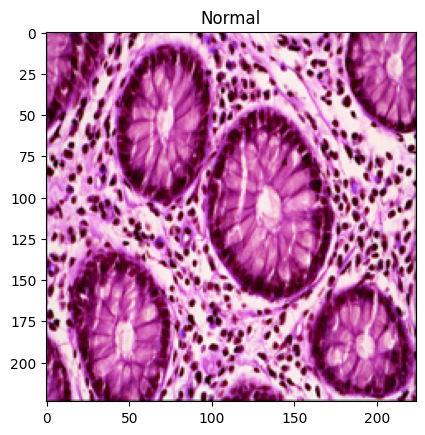

In [24]:
idx = np.random.randint(0, len(image_df))
img = cv2.imread(image_df.iloc[idx]['path'])

plt.imshow(img)
plt.title(image_df.iloc[idx]['class'])
plt.show()

In [25]:
print(type(img))

<class 'numpy.ndarray'>


In [26]:
print(img.min(), img.max())

0 255


In [27]:
train_df, val_df = train_test_split(
    image_df,
    test_size=0.2,
    stratify=image_df['class'],
    random_state=42 # For reproducibility
)

print(f"Training DataFrame shape: {train_df.shape}")
print(f"Validation DataFrame shape: {val_df.shape}")

print("\nClass distribution in training set:")
print(train_df['class'].value_counts(normalize=True))

print("\nClass distribution in validation set:")
print(val_df['class'].value_counts(normalize=True))

Training DataFrame shape: (242, 2)
Validation DataFrame shape: (61, 2)

Class distribution in training set:
class
Adenocarcinoma      0.177686
Serrated_adenoma    0.169421
High-gradeIN        0.169421
Low-gradeIN         0.169421
Normal              0.165289
Polyp               0.148760
Name: proportion, dtype: float64

Class distribution in validation set:
class
Adenocarcinoma      0.180328
Normal              0.180328
Low-gradeIN         0.163934
High-gradeIN        0.163934
Serrated_adenoma    0.163934
Polyp               0.147541
Name: proportion, dtype: float64


In [28]:
# map classes to numbers
all_classes = image_df['class'].unique()
class_to_idx = {cls_name: i for i, cls_name in enumerate(sorted(all_classes))} # create a mapping between each class and a number
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}

class GlandsDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, img_base_dir, transform=None, class_to_idx=None):
        self.dataframe = dataframe
        self.img_base_dir = img_base_dir
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_base_dir, self.dataframe.iloc[idx]['path'])
        #print(f'opening image at path: {self.dataframe.iloc[idx]['path']}')
        image = Image.open(self.dataframe.iloc[idx]['path']).convert('RGB') # PIL image because this is the format that torchvision.transforms require


        label_name = self.dataframe.iloc[idx]['class']

        if self.transform:
            image = self.transform(image)

        # Convert class label to numerical index
        label = self.class_to_idx[label_name]

        return image, label

print("Image transformations defined.")
print("CustomImageDataset class defined.")
print(f"Class to index mapping: {class_to_idx}")

Image transformations defined.
CustomImageDataset class defined.
Class to index mapping: {'Adenocarcinoma': 0, 'High-gradeIN': 1, 'Low-gradeIN': 2, 'Normal': 3, 'Polyp': 4, 'Serrated_adenoma': 5}


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()         # Convert images to PyTorch tensor (this automatically rescale images in range (0,1))
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


train_dataset = GlandsDataset(
    dataframe=train_df,
    img_base_dir='',
    transform=train_transform,
    class_to_idx=class_to_idx
)

val_dataset = GlandsDataset(
    dataframe=val_df,
    img_base_dir='',
    transform=val_transform,
    class_to_idx=class_to_idx
)


batch_size = 16


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

# 5. Print the number of samples and batches
print(f"Training dataset size: {len(train_dataset)} samples")
print(f"Validation dataset size: {len(val_dataset)} samples")
print(f"Training DataLoader has {len(train_loader)} batches of size {batch_size}")
print(f"Validation DataLoader has {len(val_loader)} batches of size {batch_size}")

print("DataLoaders created successfully.")

Training dataset size: 242 samples
Validation dataset size: 61 samples
Training DataLoader has 16 batches of size 16
Validation DataLoader has 4 batches of size 16
DataLoaders created successfully.


## Create a Convolutional Neural Networl

In [29]:
N_CLASSES = len(class_to_idx)

class ConvNeuralNetwork(nn.Module):
    def __init__(self, num_classes):
        super(ConvNeuralNetwork, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return x

# instantiate the model
model = ConvNeuralNetwork(num_classes=N_CLASSES)


criterion = nn.CrossEntropyLoss()
print(f"Model instantiated with {N_CLASSES} output classes.")
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")
print("\nModel Architecture:")
print(model)


Model instantiated with 6 output classes.
Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

Model Architecture:
ConvNeuralNetwork(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)


In [ ]:
# Get one batch of training images and labels
dataiter = iter(train_loader)
images, labels = next(dataiter)

fig = plt.figure(figsize=(15, 8))
for i in range(min(len(images), 8)):
    ax = fig.add_subplot(2, 4, i + 1, xticks=[], yticks=[])
    img = images[i].numpy().transpose((1, 2, 0))
    ax.imshow(img)
    # Get the class name using the idx_to_class mapping
    ax.set_title(idx_to_class[labels[i].item()])
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

## Train the Base CNN Model


In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode

    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and update weights
        loss.backward()
        optimizer.step()

        # Update statistics
        running_loss += loss.item() * inputs.size(0)

        # Collect all labels and predictions for F1 score calculation
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total

    # compute F1 score for this epoch
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, f1



def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            # NO backward pass and no weights update! We are only monitoring performance
            running_loss += loss.item() * inputs.size(0)

            # Collect all labels and predictions for F1 score calculation
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

            total += labels.size(0)

    epoch_loss = running_loss / total

    # compute F1 score for this epoch
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, f1



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # load your model on the device
print(f"Using device: {device}")
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 30
print(f"Number of epochs set to: {num_epochs}")

train_losses = []
train_f1s = []
val_losses = []
val_f1s = []

for epoch in range(num_epochs):
    # --- Train phase ---
    epoch_train_loss, epoch_train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    train_losses.append(epoch_train_loss)
    train_f1s.append(epoch_train_f1)

    # --- Validation phase ---
    epoch_val_loss, epoch_val_f1 = validate_one_epoch(
        model, val_loader, criterion, device
    )
    val_losses.append(epoch_val_loss)
    val_f1s.append(epoch_val_f1)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_f1:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_f1:.4f}")

print("Training complete.")


Using device: cuda
Number of epochs set to: 30
Epoch 1/30 | Train Loss: 6.3995, Train Acc: 0.1594 | Val Loss: 1.7912, Val Acc: 0.0551
Epoch 2/30 | Train Loss: 1.7925, Train Acc: 0.0469 | Val Loss: 1.7914, Val Acc: 0.0551
Epoch 3/30 | Train Loss: 1.7922, Train Acc: 0.0469 | Val Loss: 1.7911, Val Acc: 0.0551
Epoch 4/30 | Train Loss: 1.7960, Train Acc: 0.0965 | Val Loss: 1.7901, Val Acc: 0.0551
Epoch 5/30 | Train Loss: 1.7860, Train Acc: 0.0630 | Val Loss: 1.7697, Val Acc: 0.0551
Epoch 6/30 | Train Loss: 1.7526, Train Acc: 0.1744 | Val Loss: 1.7934, Val Acc: 0.0628
Epoch 7/30 | Train Loss: 1.5440, Train Acc: 0.4907 | Val Loss: 2.1302, Val Acc: 0.0707
Epoch 8/30 | Train Loss: 1.2790, Train Acc: 0.5000 | Val Loss: 2.0216, Val Acc: 0.1233
Epoch 9/30 | Train Loss: 0.7485, Train Acc: 0.7562 | Val Loss: 2.3100, Val Acc: 0.1920
Epoch 10/30 | Train Loss: 0.4256, Train Acc: 0.8879 | Val Loss: 4.0901, Val Acc: 0.1238
Epoch 11/30 | Train Loss: 0.3053, Train Acc: 0.9380 | Val Loss: 4.4196, Val Acc: 0

## Define Augmented Image Transformations and Dataset


In [ ]:
# transformations for the training set
train_augmented_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),             # Convert images to PyTorch tensors
])


train_augmented_dataset = GlandsDataset(
    dataframe=train_df,
    img_base_dir='',
    transform=train_augmented_transform,
    class_to_idx=class_to_idx
)
val_augmented_dataset = GlandsDataset(
    dataframe=val_df,
    img_base_dir='',
    transform=val_transform, # we don't touch the validation dataset!
    class_to_idx=class_to_idx
)

print("Augmented image transformations defined.")
print("Augmented CustomImageDataset for training created.")
print("CustomImageDataset for validation created (re-using standard transforms).")

Augmented image transformations defined.
Augmented CustomImageDataset for training created.
CustomImageDataset for validation created (re-using standard transforms).


In [ ]:
train_augmented_loader = DataLoader(
    train_augmented_dataset,
    batch_size=batch_size,
    shuffle=True,

)

val_augmented_loader = DataLoader(
    val_augmented_dataset,
    batch_size=batch_size,
    shuffle=False
)


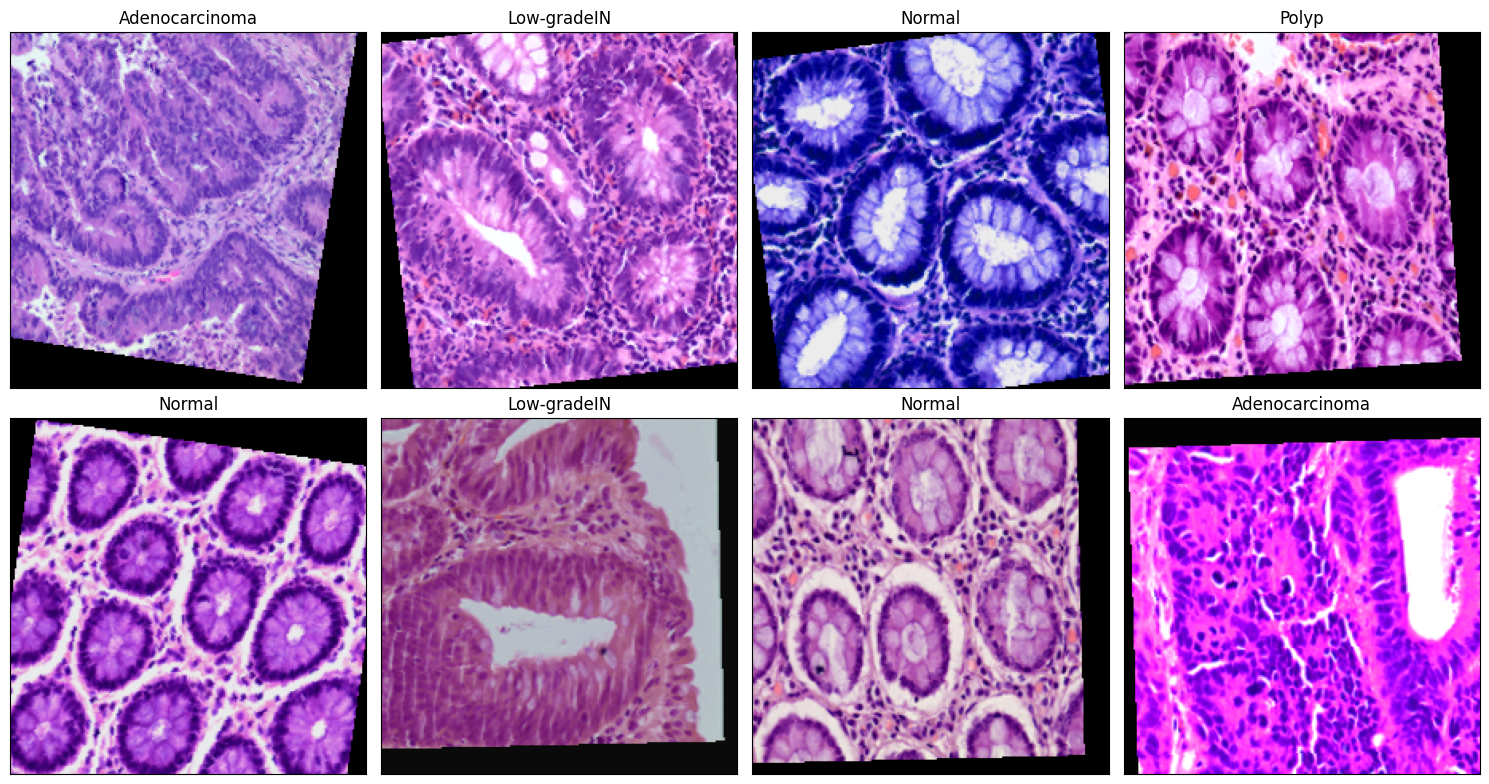

In [ ]:

dataiter = iter(train_augmented_loader)
images, labels = next(dataiter)

fig = plt.figure(figsize=(15, 8))
for i in range(min(len(images), 8)):
    ax = fig.add_subplot(2, 4, i + 1, xticks=[], yticks=[])
    img = images[i].numpy().transpose((1, 2, 0))
    ax.imshow(img)
    # Get the class name using the idx_to_class mapping
    ax.set_title(idx_to_class[labels[i].item()])
plt.tight_layout()
plt.show()


## Regularized convolutional neural network

In [ ]:

class RegularizedConvNeuralNetwork(nn.Module):
    def __init__(self, num_classes):
        super(RegularizedConvNeuralNetwork, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5), # Added dropout layer
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return x

regularized_model = RegularizedConvNeuralNetwork(num_classes=N_CLASSES)
regularized_criterion = nn.CrossEntropyLoss()



print(f"Regularized Model instantiated with {N_CLASSES} output classes.")
print("\nRegularized Model Architecture:")
print(regularized_model)


Regularized Model instantiated with 6 output classes.

Regularized Model Architecture:
RegularizedConvNeuralNetwork(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=6, bias=True)
  )
)


## Train the Regularized CNN Model with Augmentation and Early Stopping


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
regularized_model.to(device)
print(f"Using device: {device}")
regularized_optimizer = optim.Adam(regularized_model.parameters(), lr=0.001, weight_decay=0.001) # Added weight_decay
num_epochs_regularized = 50
print(f"Number of epochs set to: {num_epochs_regularized}")

# lists to store metrics
regularized_train_losses = []
regularized_train_f1s = []
regularized_val_losses = []
regularized_val_f1s = []
print("Metric lists initialized.")

# variables for early stopping
best_val_f1 = 0
epochs_no_improve = 0
patience = 10  # Number of epochs to wait for improvement before stopping
print(f"Early stopping initialized with patience: {patience}")


best_model_path = 'best_regularized_model.pth'
for epoch in range(num_epochs_regularized):

    # --- Training phase ---
    epoch_train_loss, epoch_train_f1 = train_one_epoch(
        regularized_model, train_augmented_loader, regularized_criterion, regularized_optimizer, device
    )
    regularized_train_losses.append(epoch_train_loss)
    regularized_train_f1s.append(epoch_train_f1)

    # ---  Validation phase ---
    epoch_val_loss, epoch_val_f1 = validate_one_epoch(
        regularized_model, val_augmented_loader, regularized_criterion, device
    )
    regularized_val_losses.append(epoch_val_loss)
    regularized_val_f1s.append(epoch_val_f1)

    # Print epoch statistics
    print(f"Epoch {epoch+1}/{num_epochs_regularized} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train F1: {epoch_train_f1:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val F1: {epoch_val_f1:.4f}")

    # Check for early stopping
    if epoch_val_f1 > best_val_f1:
        best_val_f1 = epoch_val_f1
        epochs_no_improve = 0
        torch.save(regularized_model.state_dict(), best_model_path)  # Save best model
        print("\tValidation F1 improved. Saving model.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\tEarly stopping triggered after {patience} epochs without improvement.")
            break

print("Training complete.")


Using device: cuda
Number of epochs set to: 50
Metric lists initialized.
Early stopping initialized with patience: 10
Epoch 1/50 | Train Loss: 3.2469, Train F1: 0.1308 | Val Loss: 1.7903, Val F1: 0.1136
	Validation F1 improved. Saving model.
Epoch 2/50 | Train Loss: 1.7921, Train F1: 0.0996 | Val Loss: 1.7894, Val F1: 0.0850
Epoch 3/50 | Train Loss: 1.7902, Train F1: 0.0909 | Val Loss: 1.7878, Val F1: 0.1291
	Validation F1 improved. Saving model.
Epoch 4/50 | Train Loss: 1.7842, Train F1: 0.1509 | Val Loss: 1.7669, Val F1: 0.0475
Epoch 5/50 | Train Loss: 1.7767, Train F1: 0.2450 | Val Loss: 1.7354, Val F1: 0.1393
	Validation F1 improved. Saving model.
Epoch 6/50 | Train Loss: 1.7620, Train F1: 0.1819 | Val Loss: 1.7573, Val F1: 0.0601
Epoch 7/50 | Train Loss: 1.7610, Train F1: 0.1937 | Val Loss: 1.6813, Val F1: 0.1396
	Validation F1 improved. Saving model.
Epoch 8/50 | Train Loss: 1.7481, Train F1: 0.1735 | Val Loss: 1.6909, Val F1: 0.1296
Epoch 9/50 | Train Loss: 1.7733, Train F1: 0.0

## Compare best results

In [ ]:
# Find the best validation F1 for the standard model
best_val_f1_standard = max(val_f1s)
best_epoch_standard = val_f1s.index(best_val_f1_standard) + 1

# Find the best validation F1 for the regularized model
best_val_f1_regularized = max(regularized_val_f1s)
best_epoch_regularized = regularized_val_f1s.index(best_val_f1_regularized) + 1

print(f"Best Validation F1 for Standard Model: {best_val_f1_standard:.4f}")
print(f"Best Validation F1 for Regularized Model: {best_val_f1_regularized:.4f}")

best_val_loss_standard = val_losses[best_epoch_standard - 1]
best_val_loss_regularized = regularized_val_losses[best_epoch_regularized - 1]

print(f"Corresponding Validation Loss for Standard Model: {best_val_loss_standard:.4f}")
print(f"Corresponding Validation Loss for Regularized Model: {best_val_loss_regularized:.4f}")

Best Validation F1 for Standard Model: 0.2365
Best Validation F1 for Regularized Model: 0.3066
Corresponding Validation Loss for Standard Model: 6.2242
Corresponding Validation Loss for Regularized Model: 1.6241


## You can also leverage a pretrained architecture

In [1]:
from torchvision.models import resnet18, ResNet18_Weights # we are importing a resnet18 architecture, a very common state-of-the-art image classification ntw
from torchvision.models import resnet50

In [30]:
weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights)
num_ftrs = model.fc.in_features # 512 per ResNet18
# we need  to change the final fully connected layer to adapt it to our 6-class classification problem
model.fc = nn.Linear(num_ftrs, N_CLASSES)